# Notebook: Diabetes Prediction

## Dataset import

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/pima-indians-diabetes-database")

print("Path to dataset files:", path)

c:\Users\coren\Documents\PERSO\COURS_PERSO\Diabete-Dashboard\Diabete-Dashboard\.diabete\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\coren\.cache\kagglehub\datasets\uciml\pima-indians-diabetes-database\versions\1


In [3]:
import pandas as pd

dataset = pd.read_csv(path + "/diabetes.csv")
dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
dataset.shape

(768, 9)

## Exploratory Data Analysis

In [5]:
dataset.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
# The missing values are represented by 0 in this dataset.
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'DiabetesPedigreeFunction']

(dataset[cols] == 0).sum()

Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
DiabetesPedigreeFunction      0
dtype: int64

Text(0, 0.5, 'Frequencies')

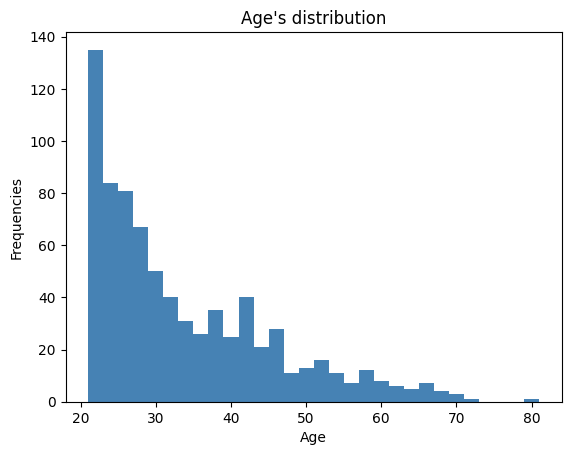

In [7]:
import matplotlib.pyplot as plt

plt.hist(dataset['Age'], bins=30, color='steelblue')
plt.title("Age's distribution")
plt.xlabel('Age')
plt.ylabel('Frequencies')

Text(0, 0.5, 'Frequencies')

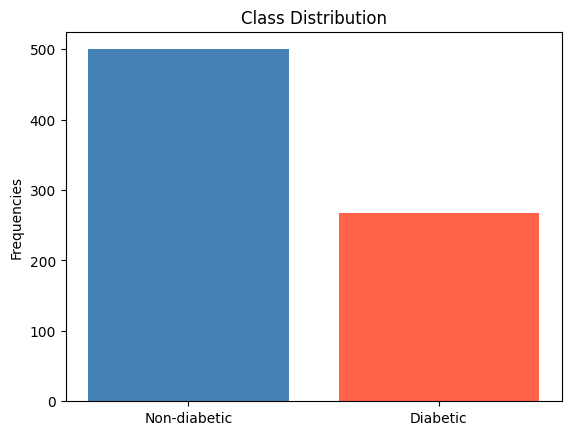

In [8]:
counts = dataset['Outcome'].value_counts()
plt.bar(counts.index, counts.values, color=('steelblue', 'tomato'))
plt.title('Class Distribution')
plt.xticks([0, 1], ['Non-diabetic', 'Diabetic'])
plt.ylabel('Frequencies')

We create a new dataset without the missing values for now, so that it won't bias the plots.

In [9]:
mask = (dataset[cols] == 0).any(axis=1)
df_no_mv = dataset[~mask]
df_no_mv.reset_index(drop=True)
df_no_mv.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
6,3,78,50,32,88,31.0,0.248,26,1
8,2,197,70,45,543,30.5,0.158,53,1
13,1,189,60,23,846,30.1,0.398,59,1


In [10]:
df_no_mv.shape

(393, 9)

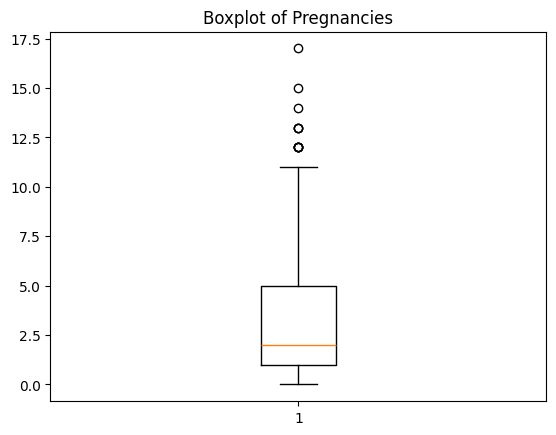

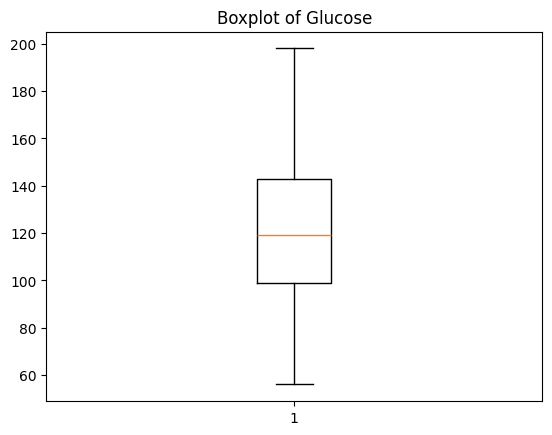

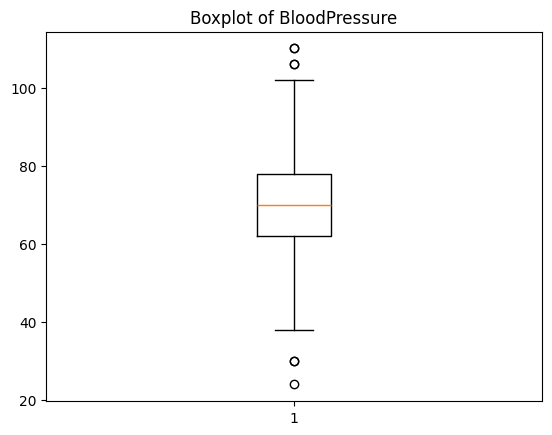

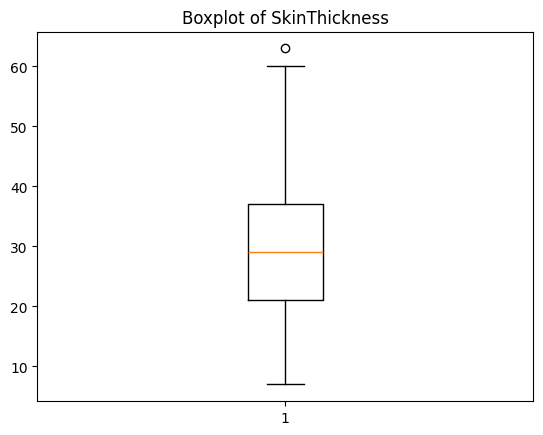

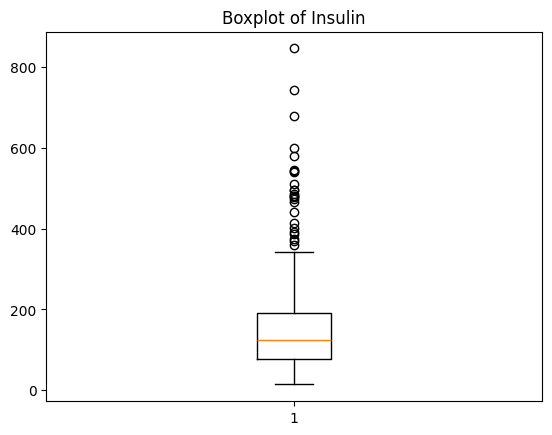

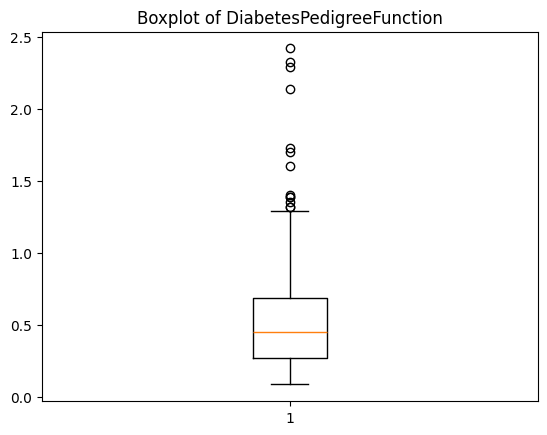

In [11]:
cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'DiabetesPedigreeFunction']

for col in cols:
    plt.boxplot(df_no_mv[col])
    plt.title(f'Boxplot of {col}')
    plt.show()
    

<Axes: >

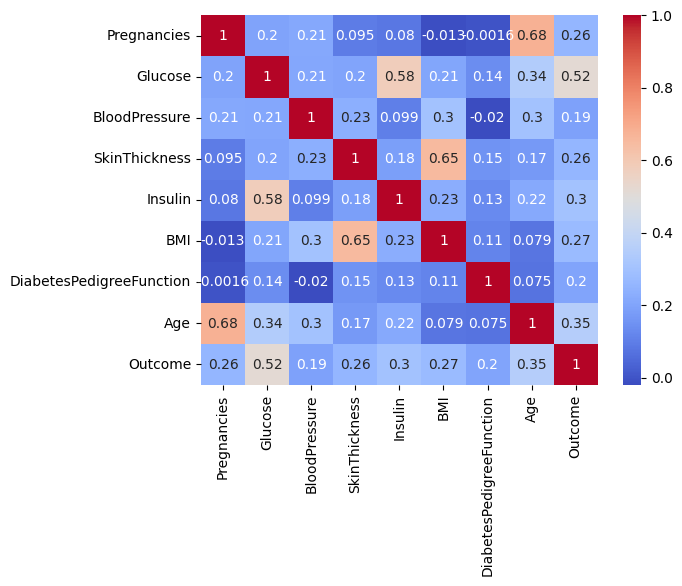

In [12]:
import seaborn as sns

sns.heatmap(df_no_mv.corr(), annot=True, cmap='coolwarm')

## Data Pre-processing

We will try 2 different approchesfor NA imputation.
- With mean
- With MICE algorithm

In [13]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import numpy as np

cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'DiabetesPedigreeFunction']

df_mean = dataset.copy()
df_mean[cols] = df_mean[cols].replace(0, np.nan)
df_mean[cols] = df_mean[cols].fillna(df_mean[cols].mean())

df_mice = dataset.copy()
df_mice[cols] = df_mice[cols].replace(0, np.nan)
imputer = IterativeImputer(max_iter=10, random_state=42)
df_mice[cols] = imputer.fit_transform(df_mice[cols])

print(f"For Mean dataset:\n{(df_mean[cols] == 0).sum()}")
print("")
print(f"For MICE dataset:\n{(df_mice[cols] == 0).sum()}")

For Mean dataset:
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
DiabetesPedigreeFunction    0
dtype: int64

For MICE dataset:
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
DiabetesPedigreeFunction    0
dtype: int64


In [14]:
from sklearn.preprocessing import StandardScaler

cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
scaler = StandardScaler()

df_mean_standardize = df_mean.copy()
df_mean_standardize[cols] = scaler.fit_transform(df_mean[cols])

df_mice_standardize = df_mice.copy()
df_mice_standardize[cols] = scaler.fit_transform(df_mice[cols])

In [15]:
df_mean_standardize.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0.639947,0.865108,-0.033518,6.655021e-01,-3.345079e-16,0.204013,0.468492,1.425995,1
1,-0.844885,-1.206162,-0.529859,-1.746338e-02,-3.345079e-16,-0.684422,-0.365061,-0.190672,0
2,1.233880,2.015813,-0.695306,8.087936e-16,-3.345079e-16,-1.103255,0.604397,-0.105584,1
3,-0.844885,-1.074652,-0.529859,-7.004289e-01,-7.243887e-01,-0.494043,-0.920763,-1.041549,0
4,-1.141852,0.503458,-2.680669,6.655021e-01,1.465506e-01,1.409746,5.484909,-0.020496,1


In [16]:
print(df_mean_standardize.shape)
print(df_mice_standardize.shape)

(768, 9)
(768, 9)


## Training

In [19]:
from sklearn.model_selection import train_test_split

# for the mean dataset
X_mean = df_mean_standardize.drop('Outcome', axis=1)
y_mean = df_mean_standardize['Outcome']

X_mean_train, X_mean_test, y_mean_train, y_mean_test = train_test_split(
    X_mean, y_mean,
    test_size= 0.2,
    random_state=42,
    stratify=y_mean
)

print(f"Mean Train: {X_mean_train.shape[0]}")
print(f"Mean Test: {X_mean_test.shape[0]}")

# for the MICE dataset
X_mice = df_mice_standardize.drop('Outcome', axis=1)
y_mice = df_mice_standardize['Outcome']

X_mice_train, X_mice_test, y_mice_train, y_mice_test = train_test_split(
    X_mice, y_mice,
    test_size= 0.2,
    random_state=42,
    stratify=y_mice
)

print(f"Mice Train: {X_mice_train.shape[0]}")
print(f"Mice Test: {X_mice_test.shape[0]}")


Mean Train: 614
Mean Test: 154
Mice Train: 614
Mice Test: 154


In [20]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# we make a dictionnary with weights for each class to reduce the imbalance
class_weight = {
    0: len(y_mean_train) / 2 * len(y_mean_train[y_mean_train==0]), 
    1: len(y_mean_train) / 2 * len(y_mean_train[y_mean_train==1])
    }

models = {
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
    'RF': RandomForestClassifier(n_estimators=100, class_weight=class_weight, random_state=42)
}

In [23]:
def train_evaluate(models, X_train, X_test, y_train, y_test, df_name):

    results = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)

        results[name] = {
            'models': model,
            'auc': auc,
            'y_pred': y_pred }
    
    return results

In [24]:
results_mean = train_evaluate(models, X_mean_train, X_mean_test, y_mean_train, y_mean_test, 'Mean')
results_mice = train_evaluate(models, X_mice_train, X_mice_test, y_mice_train, y_mice_test, 'Mice')

## Data Visualization

In [31]:
print('--- MEAN DATASET ---')
for model, res in results_mean.items():
    print(f"\n{'='*15 + ' '+ model + ' ' + '='*15}")
    print(classification_report(y_mean_test, res['y_pred'], target_names=['Non diabetique', 'Diabetique']))
    print(f"AUC-ROC: {res['auc']:.3f}")

print('--- MICE DATASET ---')
for model, res in results_mice.items():
    print(f"\n{'='*15 + ' '+ model + ' ' + '='*15}")
    print(classification_report(y_mice_test, res['y_pred'], target_names=['Non diabetique', 'Diabetique']))
    print(f"AUC-ROC: {res['auc']:.3f}")

--- MEAN DATASET ---

=============== KNN ===============
                precision    recall  f1-score   support

Non diabetique       0.79      0.81      0.80       100
    Diabetique       0.63      0.59      0.61        54

      accuracy                           0.73       154
     macro avg       0.71      0.70      0.70       154
  weighted avg       0.73      0.73      0.73       154

AUC-ROC: 0.801

=============== SVM ===============
                precision    recall  f1-score   support

Non diabetique       0.84      0.73      0.78       100
    Diabetique       0.60      0.74      0.66        54

      accuracy                           0.73       154
     macro avg       0.72      0.74      0.72       154
  weighted avg       0.75      0.73      0.74       154

AUC-ROC: 0.811

=============== RF ===============
                precision    recall  f1-score   support

Non diabetique       0.78      0.83      0.80       100
    Diabetique       0.64      0.56      0.59   

In [34]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

for model, res in results_mean.items():
    cm = confusion_matrix(y_mean_test, res['y_pred'])
    print(f"\n{'='*15 + ' '+ model + ' ' + '='*15}")
    print(cm)
    print('')

for model, res in results_mice.items():
    cm = confusion_matrix(y_mice_test, res['y_pred'])
    print(f"\n{'='*15 + ' '+ model + ' ' + '='*15}")
    print(cm)
    print('')
    



=============== KNN ===============
[[81 19]
 [22 32]]


=============== SVM ===============
[[73 27]
 [14 40]]


=============== RF ===============
[[83 17]
 [24 30]]


=============== KNN ===============
[[83 17]
 [21 33]]


=============== SVM ===============
[[73 27]
 [14 40]]


=============== RF ===============
[[79 21]
 [24 30]]

